<a href="https://colab.research.google.com/github/ShatohinaYelizaveta/Notes_app_Django/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

> 📌 **Сценарій:** Ви — AI QA-інженер у медичному стартапі.  
> Команда розробила **дві моделі** скринінгу діабету (датасет Pima Indians).  
> Ваше завдання — дати відповідь перед деплоєм:  
> **«Яку модель безпечніше запустити на реальних пацієнтах — і чому?»**

| Параметр | Модель A | Модель B |
|---|---|---|
| Тип | Logistic Regression (проста, інтерпретована) | Random Forest (складна, «чорна скринька») |
| Accuracy | ~75% | ~78% |

---

### 🗺️ Структура ноутбука

| Крок | Тема | Концепт з лекції |
|---|---|---|
| 0 | Встановлення та імпорти | — |
| 1 | Базове оцінювання та таблиця метрик | Accuracy Trap, Confusion Matrix |
| 2 | Аналіз Confusion Matrix | FP / FN / ціна помилок |
| 3 | Slice-аналіз | Slice-based Evaluation |
| 4 | Бізнес-метрика (Business Cost Score) | Cost Matrix |
| 5 | Фінальний висновок QA-інженера | — |


---
## ⚙️ Крок 0 — Встановлення та імпорти

> 💡 **Теорія:** Перш ніж будь-що запускати, переконайтесь у наявності всіх залежностей.  
> В цьому завданні ми використовуємо `scikit-learn`, `pandas`, `matplotlib` та `seaborn`.


In [1]:
# Якщо запускаєте в Google Colab — розкоментуйте наступний рядок:
!pip install scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

np.random.seed(42)
print("✅ Всі бібліотеки успішно завантажено")


✅ Всі бібліотеки успішно завантажено


---
## 📊 Крок 1 — Базове оцінювання та таблиця метрик

### 🎓 Теорія: Чому Accuracy — недостатня метрика?

З **Лекції 4** ми знаємо, що **Accuracy** вимірює частку правильних передбачень серед усіх:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Але вона **не відрізняє** тип помилки — пропуск хворого (FN) від хибної тривоги (FP).  
У медицині ці два типи помилок мають **принципово різну ціну**.

**П'ять метрик, які нам потрібні:**

| Метрика | Формула | На що звертає увагу |
|---|---|---|
| **Accuracy** | (TP+TN) / All | Загальна частка правильних |
| **Precision** | TP / (TP+FP) | Мінімізація хибних тривог |
| **Recall** | TP / (TP+FN) | Мінімізація пропусків хворих |
| **F1 Score** | 2·(P·R)/(P+R) | Баланс між Precision і Recall |
| **ROC-AUC** | Площа під ROC-кривою | Розрізняльна здатність моделі |

> ⚠️ **Пастка точності (Accuracy Trap):** якщо один клас займає 90%+ датасету,  
> модель, що завжди каже «немає діабету», матиме Accuracy ~90% — але Recall = 0!


In [2]:
# ── 1а. Завантаження датасету ──────────────────────────────────────────────
data = fetch_openml('diabetes', version=1, as_frame=True)
X = data.data
y = (data.target == 'tested_positive').astype(int)

print("Датасет Pima Indians Diabetes")
print(f"Розмір: {X.shape[0]} пацієнтів, {X.shape[1]} ознак")
print(f"\nРозподіл класів:")
class_counts = y.value_counts().rename({0: 'Здоровий (0)', 1: 'Діабет (1)'})
print(class_counts)
print(f"\nДисбаланс класів: {class_counts[0]/class_counts[1]:.1f}:1")
print("→ Класи НЕ збалансовані — Accuracy може вводити в оману!")


Датасет Pima Indians Diabetes
Розмір: 768 пацієнтів, 8 ознак

Розподіл класів:
class
Здоровий (0)    500
Діабет (1)      268
Name: count, dtype: int64

Дисбаланс класів: 1.9:1
→ Класи НЕ збалансовані — Accuracy може вводити в оману!


/tmp/ipykernel_19251/3178493456.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nДисбаланс класів: {class_counts[0]/class_counts[1]:.1f}:1")


In [3]:
# ── 1б. Розбивка та навчання моделей ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Масштабування для логістичної регресії
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Модель A — Logistic Regression
model_a = LogisticRegression(random_state=42, max_iter=1000)
model_a.fit(X_train_sc, y_train)

# Модель B — Random Forest
model_b = RandomForestClassifier(n_estimators=100, random_state=42)
model_b.fit(X_train, y_train)

pred_a = model_a.predict(X_test_sc)
pred_b = model_b.predict(X_test)

print("✅ Моделі навчені та готові до оцінювання")
print(f"Тестова вибірка: {len(y_test)} пацієнтів")


✅ Моделі навчені та готові до оцінювання
Тестова вибірка: 154 пацієнтів


In [4]:
# ── 1в. Таблиця метрик ─────────────────────────────────────────────────────
print("=" * 60)
print(f"{'Метрика':<15} {'Модель A':>15} {'Модель B':>15}")
print("=" * 60)

metrics = {
    'Accuracy':  (accuracy_score,  {}),
    'Precision': (precision_score, {}),
    'Recall':    (recall_score,    {}),
    'F1 Score':  (f1_score,        {}),
    'ROC-AUC':   (roc_auc_score,   {}),
}

results = {}
for name, (fn, kwargs) in metrics.items():
    val_a = fn(y_test, pred_a, **kwargs)
    val_b = fn(y_test, pred_b, **kwargs)
    results[name] = {'Модель A': val_a, 'Модель B': val_b}
    better = '← A краща' if val_a > val_b else ('← B краща' if val_b > val_a else '← однаково')
    print(f"{name:<15} {val_a:>15.3f} {val_b:>15.3f}   {better}")

print("=" * 60)

df_metrics = pd.DataFrame(results).T
print("\n📋 Таблиця для звіту (скопіюйте у відповідь):")
print(df_metrics.round(3).to_string())


Метрика                Модель A        Модель B
Accuracy                  0.714           0.760   ← B краща
Precision                 0.609           0.681   ← B краща
Recall                    0.519           0.593   ← B краща
F1 Score                  0.560           0.634   ← B краща
ROC-AUC                   0.669           0.721   ← B краща

📋 Таблиця для звіту (скопіюйте у відповідь):
           Модель A  Модель B
Accuracy      0.714     0.760
Precision     0.609     0.681
Recall        0.519     0.593
F1 Score      0.560     0.634
ROC-AUC       0.669     0.721


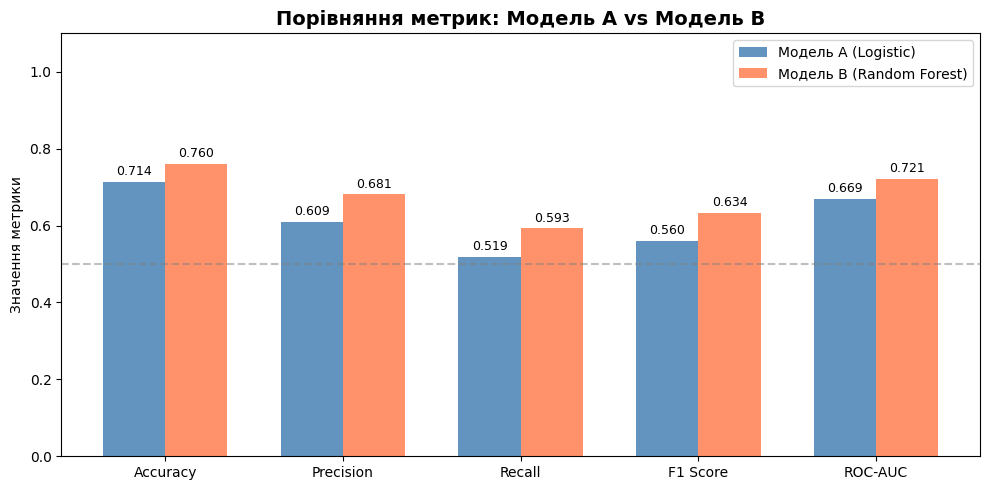

✅ Графік збережено


In [5]:
# ── 1г. Візуалізація метрик ─────────────────────────────────────────────────
metric_names = list(results.keys())
vals_a = [results[m]['Модель A'] for m in metric_names]
vals_b = [results[m]['Модель B'] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_a = ax.bar(x - width/2, vals_a, width, label='Модель A (Logistic)', color='steelblue', alpha=0.85)
bars_b = ax.bar(x + width/2, vals_b, width, label='Модель B (Random Forest)', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Значення метрики')
ax.set_title('Порівняння метрик: Модель A vs Модель B', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline (0.5)')

for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('step1_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Графік збережено")


### 📝 Завдання 1 — Заповніть таблицю метрик

Після запуску коду заповніть таблицю нижче (замініть `???` на отримані значення):

| Метрика | Модель A (Logistic) | Модель B (Random Forest) | Яка краща? |
|---|---|---|---|
| **Accuracy** | 0.714 | 0.760 | B |
| **Precision** | 0.609 | 0.681 | B |
| **Recall** | 0.519 | 0.593 | B |
| **F1 Score** | 0.560 | 0.634 | B |
| **ROC-AUC** | 0.669 | 0.721 | B |

> **Ваш коментар до таблиці** *(2-3 речення)*:  
> *(Модель B перемагає по всіх метриках, але навіть вона має Recall лише 0.593 — це означає що майже кожен другий хворий пацієнт не буде виявлений. Для медичного скринінгу це критично низький показник)*


---
## 🔍 Крок 2 — Аналіз Confusion Matrix

### 🎓 Теорія: Читання матриці сплутаності

Confusion Matrix — **фундамент** усіх класифікаційних метрик (Лекція 4, Слайд 3).

```
                   Передбачений клас
                   Здоровий   Діабет
Реальний  Здоровий    TN  |   FP   ← хибна тривога
  клас      Діабет    FN  |   TP   ← правильне виявлення
                          ↑
                       Пропуск!
```

| Тип | Значення | Медичний наслідок |
|---|---|---|
| **TP** | Правильно знайшли хворого | Пацієнт отримає лікування ✅ |
| **TN** | Правильно визначили здорового | Здоровий не проходить зайвих процедур ✅ |
| **FP** | Здоровий отримав діагноз | Зайві аналізи, стрес, витрати 😟 |
| **FN** | Хворий пропущений | **Хворий не отримає лікування вчасно — найнебезпечніше!** 💀 |

> 🎯 **Ключовий принцип:** У медицині FN (пропуск хвороби) зазвичай **набагато небезпечніший**, ніж FP.  
> Тому в медичному скринінгу **Recall (чутливість) важливіша за Precision**.


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_19251/3641929164.py:29: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.savefig('step2_confusion_matrices.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_19251/3641929164.py:29: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.savefig('step2_confusion_matrices.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing f

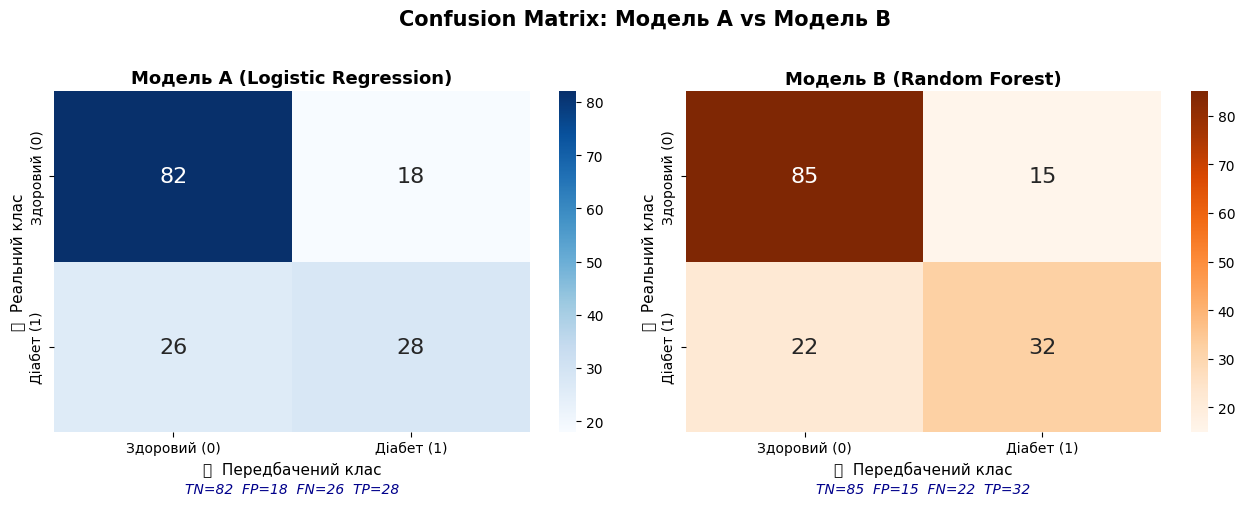

In [6]:
# ── 2а. Confusion Matrix для обох моделей ──────────────────────────────────
cm_a = confusion_matrix(y_test, pred_a)
cm_b = confusion_matrix(y_test, pred_b)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm, name, color in zip(
    axes,
    [cm_a, cm_b],
    ['Модель A (Logistic Regression)', 'Модель B (Random Forest)'],
    ['Blues', 'Oranges']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax,
                annot_kws={'size': 16},
                xticklabels=['Здоровий (0)', 'Діабет (1)'],
                yticklabels=['Здоровий (0)', 'Діабет (1)'])
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_ylabel('🏷️  Реальний клас', fontsize=11)
    ax.set_xlabel('🤖  Передбачений клас', fontsize=11)

    # Додаємо підписи FN / FP
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.18, f"TN={tn}  FP={fp}  FN={fn}  TP={tp}",
            transform=ax.transAxes, ha='center', fontsize=10,
            color='darkblue', style='italic')

plt.suptitle('Confusion Matrix: Модель A vs Модель B', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# ── 2б. Детальний розбір кожної моделі ─────────────────────────────────────
print("=" * 55)
for name, cm in [('МОДЕЛЬ A (Logistic)', cm_a), ('МОДЕЛЬ B (Random Forest)', cm_b)]:
    tn, fp, fn, tp = cm.ravel()
    total_sick = fn + tp   # всього хворих в тесті
    total_healthy = tn + fp

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(f"  Всього хворих пацієнтів у тесті: {total_sick}")
    print(f"  Всього здорових у тесті:          {total_healthy}")
    print()
    print(f"  ✅ Правильно знайдено хворих (TP):         {tp:4d}  ({tp/total_sick:.1%})")
    print(f"  💀 ПРОПУЩЕНО хворих (FN) — небезпечно!:   {fn:4d}  ({fn/total_sick:.1%})")
    print(f"  😟 Хибна тривога у здорових (FP):          {fp:4d}  ({fp/total_healthy:.1%})")
    print(f"  ✅ Правильно здорових (TN):                {tn:4d}  ({tn/total_healthy:.1%})")
    print()
    print(f"  👉 Recall (знайдено хворих): {recall_score(y_test, [pred_a, pred_b][name.startswith('МОДЕЛЬ B')]):.3f}")

print(f"\n{'='*55}")



───────────────────────────────────────────────────────
  МОДЕЛЬ A (Logistic)
───────────────────────────────────────────────────────
  Всього хворих пацієнтів у тесті: 54
  Всього здорових у тесті:          100

  ✅ Правильно знайдено хворих (TP):           28  (51.9%)
  💀 ПРОПУЩЕНО хворих (FN) — небезпечно!:     26  (48.1%)
  😟 Хибна тривога у здорових (FP):            18  (18.0%)
  ✅ Правильно здорових (TN):                  82  (82.0%)

  👉 Recall (знайдено хворих): 0.519

───────────────────────────────────────────────────────
  МОДЕЛЬ B (Random Forest)
───────────────────────────────────────────────────────
  Всього хворих пацієнтів у тесті: 54
  Всього здорових у тесті:          100

  ✅ Правильно знайдено хворих (TP):           32  (59.3%)
  💀 ПРОПУЩЕНО хворих (FN) — небезпечно!:     22  (40.7%)
  😟 Хибна тривога у здорових (FP):            15  (15.0%)
  ✅ Правильно здорових (TN):                  85  (85.0%)

  👉 Recall (знайдено хворих): 0.593



### 📝 Завдання 2 — Дайте відповіді на 5 запитань

Після запуску коду вище дайте відповідь на кожне запитання:

---

**Запитання 1:** Скільки хворих пацієнтів ПРОПУСТИЛА кожна модель (FN)?

> **Модель A — FN =** `26`  
> **Модель B — FN =** `22`

---

**Запитання 2:** Скільки здорових людей отримали б помилковий діагноз (FP)?

> **Модель A — FP =** `18`  
> **Модель B — FP =** `15`

---

**Запитання 3:** Яка ціна помилки більша в медицині: FN чи FP? Чому?

> **Ваша відповідь** *(2-3 речення)*:  
> *(FN небезпечніше, тому що хворий пацієнт не отримує діагноз і залишається без лікування — це може призвести до ускладнень або смерті. FP — це лише зайві аналізи, неприємно але не загрожує життю.)*

---

**Запитання 4:** Яка модель знаходить більше реально хворих пацієнтів (незважаючи на Accuracy)?

> **Ваша відповідь:**  
> *(Модель B знаходить більше хворих — Recall 0.593 проти 0.519 у Моделі A, і пропускає 22 хворих проти 26. Але навіть вона пропускає 40% реально хворих пацієнтів.)*

---

**Запитання 5:** Яку модель ви б обрали для власного скринінгу як пацієнт? Чому?

> **Ваша відповідь** *(2-3 речення)*:  
> *(Як пацієнт я б обрала Модель B — вона рідше пропускає хворих. Для пацієнта краще здати зайві аналізи і зрозуміти що він здоровий ніж пропустити хворобу)*


---
## 🔬 Крок 3 — Slice-аналіз: пошук прихованих проблем

### 🎓 Теорія: Slice-Based Evaluation

З **Лекції 4, Слайд 13** — **Slice-Based Evaluation** — це обчислення метрик  
**не на всьому датасеті, а на окремих значущих підгрупах**.

**Чому це критично?**

> Загальна висока метрика часто **маскує критичні провали** на окремих сегментах,  
> які можуть бути найважливішими для безпеки або нести регуляторні ризики.

**Аналогія з лекції** (кредитний скоринг, Слайд 13):
- Загальна Accuracy = **88%** ← виглядає добре
- Молодь 18-25: **71%** ← проблема!  
- Сільська місцевість: **69%** ← ризик дискримінації!

У нашому завданні ми перевіряємо **Recall по двох зрізах:**
1. **Рівень глюкози** — найважливіший клінічний показник діабету  
2. **Вікова група** — різні вікові когорти можуть мати різну якість скринінгу


In [8]:
# ── 3а. Підготовка датасету для slice-аналізу ──────────────────────────────
X_test_df = X_test.copy()
X_test_df['y_true'] = y_test.values
X_test_df['pred_a'] = pred_a
X_test_df['pred_b'] = pred_b

# Перевірка фактичних назв колонок датасету
print("Колонки X_test_df:")
print(list(X_test_df.columns))
print()

# Маппінг Pima Indians датасету (fetch_openml назви — короткі):
# preg = кількість вагітностей
# plas = рівень глюкози в плазмі  ← ключова ознака для зрізу 1
# pres = кров'яний тиск
# skin = товщина шкірної складки
# insu = рівень інсуліну
# mass = індекс маси тіла (BMI)
# pedi = функція діабетичної спадковості
# age  = вік  ← ключова ознака для зрізу 2

# Зріз 1: рівень глюкози (колонка 'plas' у цьому датасеті)
X_test_df['glucose_group'] = pd.cut(
    X_test_df['plas'],
    bins=[0, 100, 140, 300],
    labels=['Низька глюкоза (<100)', 'Нормальна (100-140)', 'Висока (>140)']
)

# Зріз 2: вікова група (колонка 'age' у цьому датасеті)
X_test_df['age_group'] = pd.cut(
    X_test_df['age'],
    bins=[0, 30, 45, 100],
    labels=['Молоді (до 30)', 'Середній вік (30-45)', 'Старші (45+)']
)

print("✅ Зрізи створені")
print(f"\nРозподіл по рівню глюкози (plas):")
print(X_test_df['glucose_group'].value_counts().sort_index())
print(f"\nРозподіл по віку (age):")
print(X_test_df['age_group'].value_counts().sort_index())


Колонки X_test_df:
['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'y_true', 'pred_a', 'pred_b']

✅ Зрізи створені

Розподіл по рівню глюкози (plas):
glucose_group
Низька глюкоза (<100)    42
Нормальна (100-140)      72
Висока (>140)            39
Name: count, dtype: int64

Розподіл по віку (age):
age_group
Молоді (до 30)          89
Середній вік (30-45)    40
Старші (45+)            25
Name: count, dtype: int64


In [9]:
# ── 3б. Recall по зрізах ───────────────────────────────────────────────────
print("=" * 70)
print(f"{'Slice-аналіз: Recall по підгрупах':^70}")
print("=" * 70)

slice_results = []

for slice_col, slice_name in [('glucose_group', 'РІВЕНЬ ГЛЮКОЗИ'), ('age_group', 'ВІКОВА ГРУПА')]:
    print(f"\n{'─'*70}")
    print(f"  📊 Зріз: {slice_name}")
    print(f"{'─'*70}")
    print(f"  {'Група':<25} {'n':>5} {'Хворих':>8} {'Recall A':>10} {'Recall B':>10} {'Різниця':>10}")
    print(f"  {'─'*60}")

    for group in X_test_df[slice_col].cat.categories:
        subset = X_test_df[X_test_df[slice_col] == group]
        n_sick = subset['y_true'].sum()

        if n_sick > 0:
            r_a = recall_score(subset['y_true'], subset['pred_a'], zero_division=0)
            r_b = recall_score(subset['y_true'], subset['pred_b'], zero_division=0)
            diff = r_b - r_a
            diff_str = f"+{diff:.2f}" if diff > 0 else f"{diff:.2f}"

            # Позначка якщо Recall < 0.5
            warning = " ⚠️ РИЗИК!" if min(r_a, r_b) < 0.50 else ""

            print(f"  {str(group):<25} {len(subset):>5} {n_sick:>8} {r_a:>10.2f} {r_b:>10.2f} {diff_str:>10}{warning}")

            slice_results.append({
                'Зріз': slice_name, 'Група': str(group),
                'n': len(subset), 'Хворих': n_sick,
                'Recall_A': r_a, 'Recall_B': r_b
            })

print(f"\n{'='*70}")
print("Позначення: ⚠️ РИЗИК! = Recall < 0.50 (пропускається більше половини хворих)")

df_slices = pd.DataFrame(slice_results)


                  Slice-аналіз: Recall по підгрупах                   

──────────────────────────────────────────────────────────────────────
  📊 Зріз: РІВЕНЬ ГЛЮКОЗИ
──────────────────────────────────────────────────────────────────────
  Група                         n   Хворих   Recall A   Recall B    Різниця
  ────────────────────────────────────────────────────────────
  Низька глюкоза (<100)        42        3       0.00       0.33      +0.33 ⚠️ РИЗИК!
  Нормальна (100-140)          72       27       0.22       0.33      +0.11 ⚠️ РИЗИК!
  Висока (>140)                39       24       0.92       0.92       0.00

──────────────────────────────────────────────────────────────────────
  📊 Зріз: ВІКОВА ГРУПА
──────────────────────────────────────────────────────────────────────
  Група                         n   Хворих   Recall A   Recall B    Різниця
  ────────────────────────────────────────────────────────────
  Молоді (до 30)               89       18       0.44       0.44     

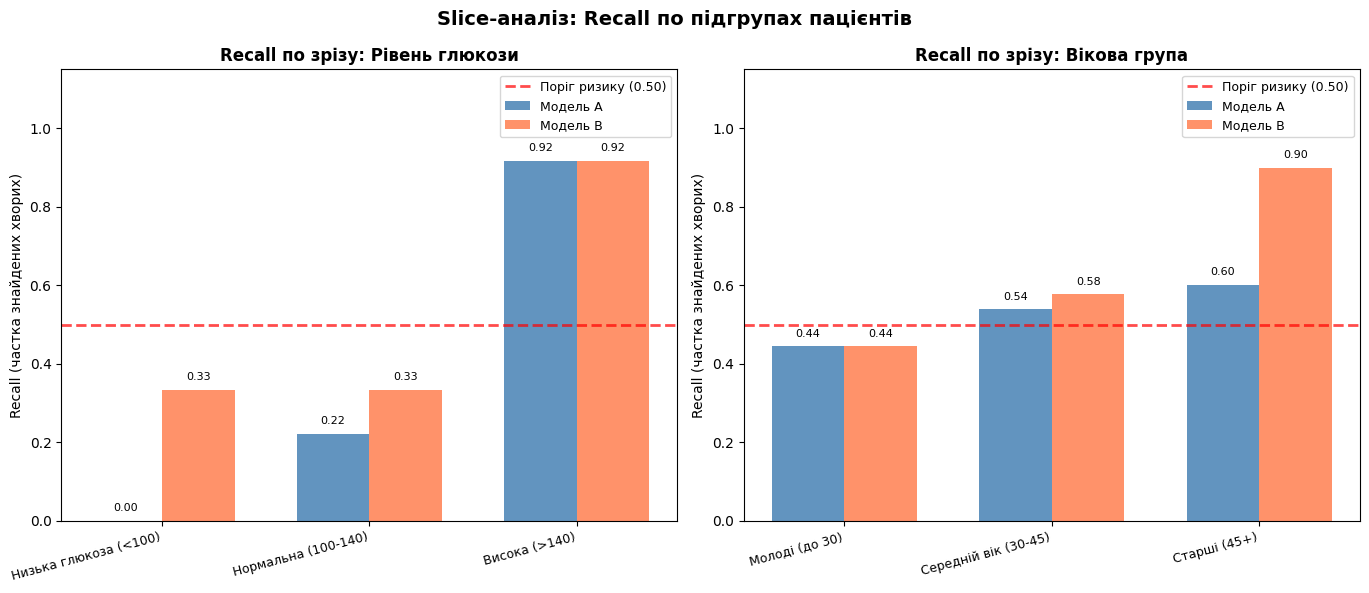

In [10]:
# ── 3в. Візуалізація slice-аналізу ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, slice_name, slice_col in zip(
    axes,
    ['Рівень глюкози', 'Вікова група'],
    ['glucose_group', 'age_group']
):
    groups = [str(g) for g in X_test_df[slice_col].cat.categories]
    recalls_a, recalls_b = [], []

    for group in X_test_df[slice_col].cat.categories:
        subset = X_test_df[X_test_df[slice_col] == str(group)]
        if subset['y_true'].sum() > 0:
            recalls_a.append(recall_score(subset['y_true'], subset['pred_a'], zero_division=0))
            recalls_b.append(recall_score(subset['y_true'], subset['pred_b'], zero_division=0))
        else:
            recalls_a.append(0)
            recalls_b.append(0)

    x = np.arange(len(groups))
    width = 0.35

    bars_a = ax.bar(x - width/2, recalls_a, width, label='Модель A', color='steelblue', alpha=0.85)
    bars_b = ax.bar(x + width/2, recalls_b, width, label='Модель B', color='coral', alpha=0.85)

    # Лінія небезпеки
    ax.axhline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Поріг ризику (0.50)')

    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Recall (частка знайдених хворих)')
    ax.set_title(f'Recall по зрізу: {slice_name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

    for bar in bars_a + bars_b:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Slice-аналіз: Recall по підгрупах пацієнтів', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('step3_slice_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 📝 Завдання 3 — Заповніть таблицю та дайте відповіді

**Таблиця результатів Recall по зрізах:**

| Зріз | Група | n | Хворих | Recall A | Recall B |
|---|---|---|---|---|---|
| Глюкоза | Низька (<100) | 42 | 3 | 0.00 | 0.33 |
| Глюкоза | Нормальна (100-140) | 72 | 27 | 0.22 | 0.33 |
| Глюкоза | Висока (>140) | 39 | 24 | 0.92 | 0.92 |
| Вік | Молоді (до 30) | 89 | 18 | 0.44 | 0.44 |
| Вік | Середній вік (30-45) | 40 | 26 | 0.54 | 0.58 |
| Вік | Старші (45+) | 25 | 10 | 0.60 | 0.90 |

---

**Запитання до Кроку 3:**

**3.1.** У якій групі яка модель найгірше знаходить хворих? (вкажіть назву групи та цифру Recall)

> **Ваша відповідь:**  
> *(Глюкоза → Низька (<100) → Модель A → Recall = 0.00. Модель A взагалі не виявляє хворих з низьким рівнем глюкози — пропускає всіх трьох.)*

---

**3.2.** Чи є група, де Recall < 0.50? Який це ризик для клінічної системи?

> **Ваша відповідь** *(2-3 речення)*:  
> *(Таких груп 2: низька глюкоза і молоді пацієнти мають Recall нижче 0.50. це означає що більше половини хворих у цих групах не отримають діагноз і залишаться без лікування. Такі пацієнти найменш "типові" для діабету, тому модель їх і пропускає)*


---
## 💰 Крок 4 — Бізнес-метрика: Business Cost Score

### 🎓 Теорія: Переводимо математику в гроші

З **Лекції 4, Слайд 15** — **Business Cost Score** — це відповідь на запитання:  
*«Скільки коштує нашій організації помилка моделі?»*

**Кроки побудови:**

**Крок 1 — Cost Matrix:** визначаємо вартість кожного типу помилки  
**Крок 2 — Формула:**

$$\text{Business Cost Score} = FP \times \text{Вартість}_{FP} + FN \times \text{Вартість}_{FN}$$

**Крок 3 — Обираємо модель** з **нижчим** Business Cost Score

**Наша Cost Matrix для медичного скринінгу:**

| Помилка | Медичний наслідок | Орієнтовна вартість |
|---|---|---|
| **FP** (хибна тривога) | Зайві аналізи, консультація, стрес пацієнта | ~200 USD |
| **FN** (пропуск діабету) | Затримка лікування, ускладнення, госпіталізація | ~8 000 USD |

> ⚠️ FN дорожчий за FP у **40 разів** — це типово для медичних задач!


In [11]:
# ── 4а. Business Cost Score ─────────────────────────────────────────────────
COST_FP = 200    # USD: зайва консультація + аналізи (хибна тривога)
COST_FN = 8000   # USD: затримка лікування діабету (пропущений випадок)

print("=" * 60)
print(f"  COST MATRIX")
print(f"  Вартість FP (хибна тривога):     ${COST_FP:>6,}")
print(f"  Вартість FN (пропуск хвороби):   ${COST_FN:>6,}")
print(f"  Співвідношення FN/FP:             {COST_FN//COST_FP}:1")
print("=" * 60)

for name, cm in [('Модель A (Logistic)', cm_a), ('Модель B (Random Forest)', cm_b)]:
    tn, fp, fn, tp = cm.ravel()
    cost_fp_total = fp * COST_FP
    cost_fn_total = fn * COST_FN
    total_cost = cost_fp_total + cost_fn_total

    print(f"\n  {name}")
    print(f"  {'─'*50}")
    print(f"  FP = {fp:3d}  →  {fp} × ${COST_FP:,} = ${cost_fp_total:>8,}")
    print(f"  FN = {fn:3d}  →  {fn} × ${COST_FN:,} = ${cost_fn_total:>8,}")
    print(f"  {'─'*50}")
    print(f"  💵 Business Cost Score: ${total_cost:>10,}")
    print(f"     (на тестовій вибірці з {len(y_test)} пацієнтів)")

print("\n" + "=" * 60)


  COST MATRIX
  Вартість FP (хибна тривога):     $   200
  Вартість FN (пропуск хвороби):   $ 8,000
  Співвідношення FN/FP:             40:1

  Модель A (Logistic)
  ──────────────────────────────────────────────────
  FP =  18  →  18 × $200 = $   3,600
  FN =  26  →  26 × $8,000 = $ 208,000
  ──────────────────────────────────────────────────
  💵 Business Cost Score: $   211,600
     (на тестовій вибірці з 154 пацієнтів)

  Модель B (Random Forest)
  ──────────────────────────────────────────────────
  FP =  15  →  15 × $200 = $   3,000
  FN =  22  →  22 × $8,000 = $ 176,000
  ──────────────────────────────────────────────────
  💵 Business Cost Score: $   179,000
     (на тестовій вибірці з 154 пацієнтів)



In [12]:
# ── 4б. Sensitivity Analysis — як змінюється вибір при різних цінах FN ────
print("Sensitivity Analysis: Business Cost Score при різних COST_FN")
print("(COST_FP фіксований = $200)\n")

tn_a, fp_a, fn_a, tp_a = cm_a.ravel()
tn_b, fp_b, fn_b, tp_b = cm_b.ravel()

fn_costs = [500, 1000, 2000, 5000, 8000, 15000, 30000]

print(f"{'COST_FN':>10} | {'Cost A':>12} | {'Cost B':>12} | {'Краща модель':>15}")
print("-" * 58)

for cost_fn in fn_costs:
    cost_a = fp_a * COST_FP + fn_a * cost_fn
    cost_b = fp_b * COST_FP + fn_b * cost_fn
    better = 'A' if cost_a < cost_b else 'B' if cost_b < cost_a else 'Однаково'
    marker = ' ← зміна!' if cost_fn in [1000] else ''
    print(f"${cost_fn:>9,} | ${cost_a:>11,} | ${cost_b:>11,} | {better:>15}{marker}")

print()
print("💡 Висновок: при яких значеннях COST_FN вибір моделі змінюється?")


Sensitivity Analysis: Business Cost Score при різних COST_FN
(COST_FP фіксований = $200)

   COST_FN |       Cost A |       Cost B |    Краща модель
----------------------------------------------------------
$      500 | $     16,600 | $     14,000 |               B
$    1,000 | $     29,600 | $     25,000 |               B ← зміна!
$    2,000 | $     55,600 | $     47,000 |               B
$    5,000 | $    133,600 | $    113,000 |               B
$    8,000 | $    211,600 | $    179,000 |               B
$   15,000 | $    393,600 | $    333,000 |               B
$   30,000 | $    783,600 | $    663,000 |               B

💡 Висновок: при яких значеннях COST_FN вибір моделі змінюється?


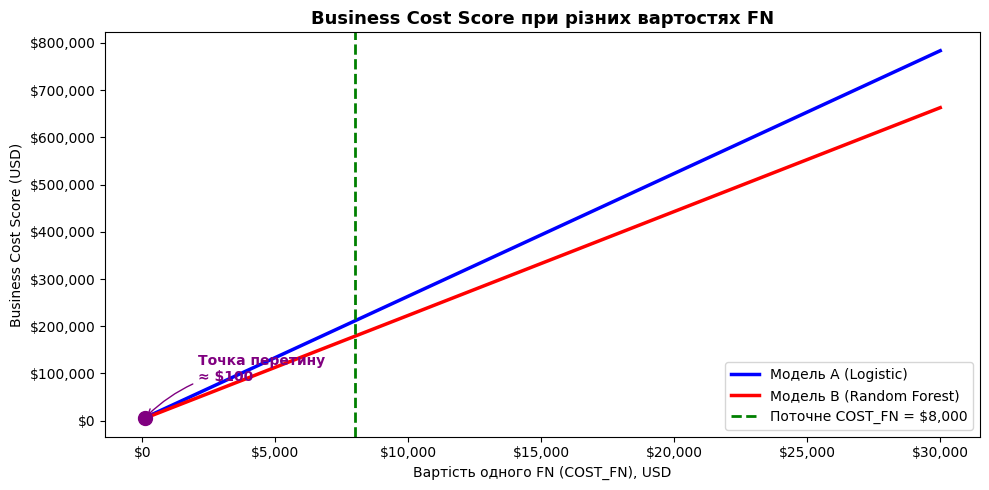

In [13]:
fn_costs_range = np.linspace(100, 30000, 200)
costs_a = [fp_a * COST_FP + fn_a * c for c in fn_costs_range]
costs_b = [fp_b * COST_FP + fn_b * c for c in fn_costs_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fn_costs_range, costs_a, 'b-', linewidth=2.5, label='Модель A (Logistic)')
ax.plot(fn_costs_range, costs_b, 'r-', linewidth=2.5, label='Модель B (Random Forest)')
ax.axvline(COST_FN, color='green', linestyle='--', linewidth=2,
           label=f'Поточне COST_FN = ${COST_FN:,}')

# Точка перетину
idx = np.argmin(np.abs(np.array(costs_a) - np.array(costs_b)))
intersect_x = fn_costs_range[idx]
intersect_y = costs_a[idx]

ax.scatter(intersect_x, intersect_y, color='purple', s=100, zorder=5)
ax.annotate(f'Точка перетину\n≈ ${intersect_x:,.0f}',
            xy=(intersect_x, intersect_y),
            xytext=(intersect_x + 2000, intersect_y + (max(costs_a) * 0.1)),
            fontsize=10,
            fontweight='bold',
            color='purple',
            arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", color='purple'))

ax.set_xlabel('Вартість одного FN (COST_FN), USD')
ax.set_ylabel('Business Cost Score (USD)')
ax.set_title('Business Cost Score при різних вартостях FN', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('step4_business_cost.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Завдання 4 — Бізнес-аналіз

**4.1.** Заповніть таблицю Business Cost Score:

| Модель | FP | FN | Cost FP | Cost FN | **Business Cost Score** |
|---|---|---|---|---|---|
| Модель A | 18 | 26 | 3600 | 208 000 | 211 600 |
| Модель B | 15 | 22 | 3000 | 176 000 | 179 000 |

---

**4.2.** При якому значенні COST_FN модель A і модель B мають однаковий Business Cost Score?

> **Відповідь:** COST_FN ≈ $100

---

**4.3.** Як зміниться ваша рекомендація, якщо COST_FN зросте до $30,000?

> **Ваша відповідь** *(Модель A коштує 211 600 на 154 пацієнтах
Модель B коштує 179 000 на 154 пацієнтах.
Різниця — 32 600 на користь Моделі B. Вона не тільки краща по Recall, але й дешевша )*:


---
## ✍️ Крок 5 — Фінальний висновок QA-інженера

### 🎓 Структура звіту перед деплоєм

Напишіть **рекомендацію на 15–20 речень** за наступною структурою.  
Кожен з 4 пунктів має бути **окремим параграфом** з конкретними цифрами.


In [14]:
# ── Фінальне резюме для допомоги у написанні висновку ──────────────────────
print("📊 ФІНАЛЬНЕ РЕЗЮМЕ — для написання висновку")
print("=" * 65)

tn_a, fp_a, fn_a, tp_a = cm_a.ravel()
tn_b, fp_b, fn_b, tp_b = cm_b.ravel()

acc_a = accuracy_score(y_test, pred_a)
acc_b = accuracy_score(y_test, pred_b)
rec_a = recall_score(y_test, pred_a)
rec_b = recall_score(y_test, pred_b)

print(f"\n  Accuracy:   A = {acc_a:.1%}  |  B = {acc_b:.1%}  → {'B краща' if acc_b>acc_a else 'A краща'}")
print(f"  Recall:     A = {rec_a:.1%}  |  B = {rec_b:.1%}  → {'B краща' if rec_b>rec_a else 'A краща'}")
print(f"  FN (пропущено хворих): A = {fn_a}  |  B = {fn_b}")
print(f"  Business Cost (при COST_FN=$8000):")
print(f"    A = ${fp_a*200 + fn_a*8000:,}  |  B = ${fp_b*200 + fn_b*8000:,}")

# Знаходимо найгірший зріз
worst_group = df_slices.loc[df_slices[['Recall_A','Recall_B']].min(axis=1).idxmin()]
print(f"\n  Найгірший зріз:")
print(f"    {worst_group['Зріз']} → '{worst_group['Група']}'")
print(f"    Recall A = {worst_group['Recall_A']:.2f}  |  Recall B = {worst_group['Recall_B']:.2f}")

print("\n" + "=" * 65)
print("  Використайте ці цифри у фінальному висновку нижче ↓")


📊 ФІНАЛЬНЕ РЕЗЮМЕ — для написання висновку

  Accuracy:   A = 71.4%  |  B = 76.0%  → B краща
  Recall:     A = 51.9%  |  B = 59.3%  → B краща
  FN (пропущено хворих): A = 26  |  B = 22
  Business Cost (при COST_FN=$8000):
    A = $211,600  |  B = $179,000

  Найгірший зріз:
    РІВЕНЬ ГЛЮКОЗИ → 'Низька глюкоза (<100)'
    Recall A = 0.00  |  Recall B = 0.33

  Використайте ці цифри у фінальному висновку нижче ↓


### 📝 Завдання 5 — Напишіть фінальний висновок

Напишіть рекомендацію перед деплоєм (15–20 речень) за структурою:

---

#### 🔴 Пункт 1 — Accuracy Trap
*(Порівняйте Accuracy та Recall обох моделей. Поясніть, чому Accuracy вводить в оману.)*

> **Ваш текст:**  
> *(Accuracy: Моделі A - 71.4%, Модель B 76%. Recall: Модель A знаходить 51.9% хворих, Модель B — 59.3%. Тобто навіть краща модель пропускає 4 із 10 хворих пацієнтів. Всходить що датасет незбалансований (500 здорових і 268 хворих), тому модель може просто частіше показує "здоровий" і при цьому має грну Accuracy, але не реально не виявляючє хворобу)*

---

#### 🟠 Пункт 2 — Прихована проблема
*(Назвіть конкретний зріз зі Step 3, де модель найбільше «провалюється».)*

> **Ваш текст:**  
> *(Slice аналіз показав критичний провал у групі з низькою глюкозою (<100): Модель A має Recall = 0.00 і вона не виявила жодного хворого з цієї групи.Модель B краща (0.33), але теж пропускає двох із трьох. Це дуже небезпечно бо пацієнти з низькою глюкозою мають атиповий діабет — вони найменше підозрюють про хворобу і найрідше самі звертаються до лікаря. Також у молодих пацієнтів (до 30) обидві моделі мають Recall = 0.44 який є нижче допустимого порогу 0.50
)*

---

#### 🟢 Пункт 3 — Рекомендація
*(Яку модель деплоїти? Аргументуйте через метрики + Business Cost Score.)*

> **Ваша відповідь:**  
> *(Рекомендую деплоїти Модель B (Random Forest). По Recall вона краща: 0.593 проти 0.519, тобто знаходить більше реально хворих. По FN — пропускає 22 пацієнти проти 26 у Моделі A. Фінансово: Business Cost Score Моделі B 179 000 проти 211 600 у Моделі A, різниця 32 600 на тестовій вибірці з 154 пацієнтів. В масштабах реальної вибірки вона буду ще дешевша)*

---

#### 🔵 Пункт 4 — Додаткові перевірки перед релізом
*(Що б ви дослідили ще? Мінімум 3 конкретні пункти.)*

> **Ваш текст:**  
> *(Перед релізом я б зробила: 1. провести додатковий slice-аналіз по групі з низькою глюкозою: зібрати більше даних саме по цих пацієнтах і перенавчити модель, бо Recall = 0.00 це неприйнятно для клінічного застосування. 2. перевірити калібрування моделі — чи ймовірності які вона видає відповідають реальній частоті діабету, бо неправильно відкалібрована модель може давати впевнені передбачення там де насправді невизначеність висока. 3. протестувати модель на зовнішньому датасеті з іншої популяції — датасет Pima Indians стосується однієї етнічної групи і модель може погано працювати на інших пацієнтах)*

---

> 💡 **Підказка структури відповіді:**  
> Перший рядок кожного параграфу — **тезис** (що саме).  
> Далі — **докази** (цифри з коду).  
> Завершення — **висновок** (що робити далі).


---
## ⭐ Бонус (за бажанням) — Behavioral Testing

### 🎓 Теорія: Behavioral Testing (Лекція 4, Слайд 14)

**Behavioral Testing** — систематична перевірка властивостей моделі  
на заздалегідь підготовлених синтетичних кейсах.

Три типи тестів:
- **MFT** (Minimum Functionality Test): очевидні кейси, які модель не має права провалити
- **INV** (Invariance Test): нейтральні зміни не мають змінювати результат
- **DIR** (Directional Expectation): певні зміни мають змінювати результат у передбачену сторону


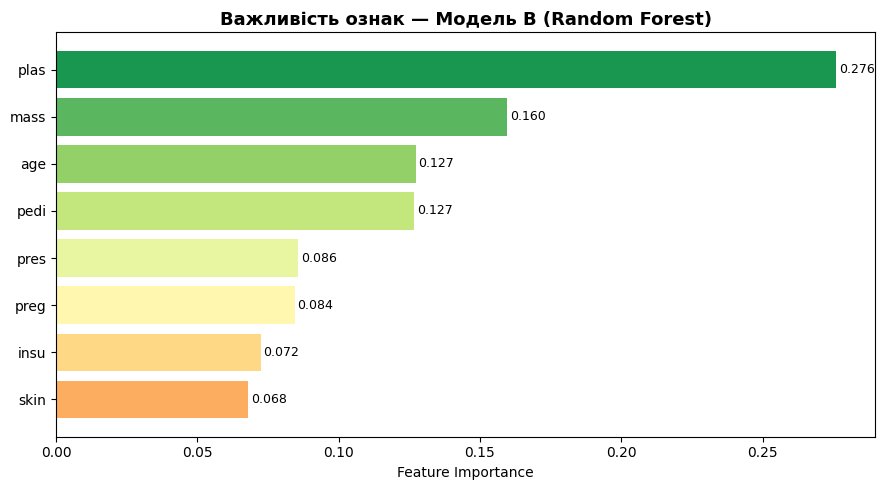


💡 Запитання для роздумів:
  - Які ознаки найважливіші для передбачення діабету?
  - Чи Glucose є найважливішою? Що це означає для slice-аналізу?
  - Чи є серед ознак такі, що можуть свідчити про data leakage?


In [15]:
# ── Бонус: Аналіз важливості ознак (Feature Importance) ────────────────────
# Для RandomForest можна отримати важливість кожної ознаки
feature_names = list(X.columns)
importances = model_b.feature_importances_

fig, ax = plt.subplots(figsize=(9, 5))
sorted_idx = np.argsort(importances)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_names)))

bars = ax.barh(np.array(feature_names)[sorted_idx],
               importances[sorted_idx],
               color=colors)
ax.set_title('Важливість ознак — Модель B (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance')

for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('bonus_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Запитання для роздумів:")
print("  - Які ознаки найважливіші для передбачення діабету?")
print("  - Чи Glucose є найважливішою? Що це означає для slice-аналізу?")
print("  - Чи є серед ознак такі, що можуть свідчити про data leakage?")


In [16]:
# ── Бонус: Threshold Analysis ────────────────────────────────────────────────
# Що буде якщо змінити поріг класифікації з 0.5 на 0.3?
# Це типовий інструмент QA-інженера для медичних систем

proba_a = model_a.predict_proba(X_test_sc)[:, 1]
proba_b = model_b.predict_proba(X_test)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("Threshold Analysis — вплив порогу класифікації на Recall та Precision")
print("=" * 75)
print(f"{'Поріг':>8} | {'Recall A':>10} {'Precis A':>10} {'F1 A':>8} | {'Recall B':>10} {'Precis B':>10} {'F1 B':>8}")
print("-" * 75)

for t in thresholds:
    p_a = (proba_a >= t).astype(int)
    p_b = (proba_b >= t).astype(int)

    r_a = recall_score(y_test, p_a)
    pr_a = precision_score(y_test, p_a, zero_division=0)
    f1_a = f1_score(y_test, p_a)

    r_b = recall_score(y_test, p_b)
    pr_b = precision_score(y_test, p_b, zero_division=0)
    f1_b = f1_score(y_test, p_b)

    marker = " ← базовий" if t == 0.5 else ""
    print(f"{t:>8.1f} | {r_a:>10.3f} {pr_a:>10.3f} {f1_a:>8.3f} | {r_b:>10.3f} {pr_b:>10.3f} {f1_b:>8.3f}{marker}")

print()
print("💡 Висновок: зниження порогу (0.5 → 0.3) збільшує Recall але знижує Precision.")
print("   Яке значення порогу є оптимальним для медичного скринінгу?")


Threshold Analysis — вплив порогу класифікації на Recall та Precision
   Поріг |   Recall A   Precis A     F1 A |   Recall B   Precis B     F1 B
---------------------------------------------------------------------------
     0.3 |      0.815      0.595    0.688 |      0.870      0.573    0.691
     0.4 |      0.648      0.614    0.631 |      0.685      0.607    0.643
     0.5 |      0.519      0.609    0.560 |      0.593      0.681    0.634 ← базовий
     0.6 |      0.444      0.686    0.539 |      0.463      0.714    0.562
     0.7 |      0.370      0.714    0.488 |      0.296      0.762    0.427

💡 Висновок: зниження порогу (0.5 → 0.3) збільшує Recall але знижує Precision.
   Яке значення порогу є оптимальним для медичного скринінгу?


### 📝 Бонусне запитання

**B.1.** При якому порозі класифікації (threshold) Recall моделі B перевищує 0.80?  
Що при цьому відбувається з Precision?

> **При порозі 0.3 Recall моделі складає 0.870. При цьому Precision падає до 0.573 — тобто більше здорових людей отримують помилковий діагноз**

---

**B.2.** Як threshold analysis пов'язаний з концепцією Precision-Recall Tradeoff з Лекції 4?

> **Ваша відповідь** *(чим нижче поріг, тим вищий Recall але нижча Precision, і навпаки. Не існує порогу де обидві метрики одночасно максимальні — завжди доводиться обирати що важливіше залежно від задачі)*:


---
## ✅ Чеклист перед здачею

Перевірте, що у вашому ноутбуці є все необхідне:

- [+] **Крок 1:** Таблиця метрик заповнена (5 метрик для обох моделей)
- [+] **Крок 2:** Відповіді на всі 5 запитань по Confusion Matrix
- [+ ] **Крок 3:** Таблиця Recall по зрізах заповнена, проблемна група ідентифікована
- [ +] **Крок 4:** Business Cost Score розрахований для обох моделей
- [ +] **Крок 5:** Фінальний висновок (4 пункти, 15-20 речень, з цифрами)
- [ +] **Весь код виконаний** (всі клітинки мають Output)

---

## 📤 Формат здачі

Посилання на **Google Colab** з відкритим доступом до коментування.

**Дедлайн:** *(вкажіть дедлайн курсу)*

---

*Успіхів! Пам'ятайте: Accuracy — це лише початок, а не кінець аналізу. 🎯*
